In [1]:
# load some library
import numpy as np
import sys
import os
from datetime import timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.dates import DateFormatter
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import sem
from calendar import Calendar
c = Calendar()
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import linregress
import xarray as xr
import netCDF4
#from google.colab.data_table import DataTable
#DataTable.max_columns = 40
import scikit_posthocs as sp
import math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import sys
#import msfunctions

sys.path.append(os.path.expanduser('../../'))
from utils.functions import normalcy, pull_data, kruskal_drops, process_abiotic_data, site_sample_area
from utils.visuals import batch_bar, batch_bar_overlay, intertidal_box_plot, abiotic_plot, regression

In [2]:
abiotic_data_path = 'C:/Users/jespi/sfsu-masters/sfsu-masters-anthopleura-sola/abiotic_data/'
start_date = '2022-08-01T00:00:00'
end_date = '2023-03-31T00:00:00'
data, seven_day_averages_data, daily_averages_data = process_abiotic_data(abiotic_data_path, start_date, end_date)

Available datasets:
- hobo
- star_oddi
- fort_point_daily
- fort_point_hourly
- precipitation

Available 7-day average datasets:
- hobo_seven_day_average
- star_oddi_seven_day_average
- fort_point_daily_seven_day_average
- fort_point_hourly_seven_day_average
- precipitation_seven_day_average

Available daily average datasets:
- hobo_daily_average
- star_oddi_daily_average
- fort_point_daily_daily_average
- fort_point_hourly_daily_average
- precipitation_daily_average


In [4]:
# Accessing the datasets
hobo_data = data['hobo']
star_oddi_data = data['star_oddi']
fort_point_daily_data = data['fort_point_daily']
fort_point_hourly_data = data['fort_point_hourly']
precipitation_data = data['precipitation']

hobo_seven_day_average_data = seven_day_averages_data['hobo_seven_day_average']
star_oddi_seven_day_average_data = seven_day_averages_data['star_oddi_seven_day_average']
fort_point_seven_day_average_data = seven_day_averages_data['fort_point_daily_seven_day_average']
fort_point_seven_day_hourly_average_data = seven_day_averages_data['fort_point_hourly_seven_day_average']
precipitation_seven_day_average_data = seven_day_averages_data['precipitation_seven_day_average']

hobo_average_data = daily_averages_data['hobo_daily_average']
star_oddi_average_data = daily_averages_data['star_oddi_daily_average']
fort_point_daily_average_data = daily_averages_data['fort_point_daily_daily_average']
fort_point_hourly_average_data = daily_averages_data['fort_point_hourly_daily_average']
precipitation_average_data = daily_averages_data['precipitation_daily_average']

## Making variables to hold the URL's we are pointing at

---



In [5]:
mur_anom_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anom1day'
mur_sst_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41'

mur_anom_month_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41anommday'
mur_sst_month__url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/jplMURSST41mday'

# In case someone wants to look at upwelling data
upwell_url = 'https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdQBstress3day_LonPM180'
#https://coastwatch.pfeg.noaa.gov/erddap/griddap/erdUI36mo_LonPM180.html

## Open a pointer to open the dataset

* These new variables will hold all the data for that link
* We'll run one below so you can see what it looks like
---

In [6]:
#sst_anom = xr.open_dataset(mur_anom_url)
sst = xr.open_dataset(mur_sst_url)

month_sst_anom = xr.open_dataset(mur_anom_month_url)
month_sst = xr.open_dataset(mur_sst_month__url)

## Running sst variable

Returns the metadata which lets you know the dimensions and coordinates:
* Number of time values and range
* Latitude and Longitude values and range

Also shows the variables are in this dataset:
* analysed sst
* analysis error
* mast
* sea ice fraction

---

# Creating a small square area for satellite data to retrieve from, offshore about 5km

In [7]:
start_time = '2022-08-27T12:00:00'
end_time = '2023-04-22T12:00:00'
data = sst

ap_beach = site_sample_area(data=data, start_time=start_time, end_time=end_time,site='ap')

lon: -122.580725 -122.54072500000001
lat: 37.527919000000004 37.567919


In [8]:
ap_beach

<xarray.DataArray 'analysed_sst' (time: 238, latitude: 4, longitude: 4)>
[3808 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 2022-08-28T09:00:00 ... 2023-04-22T09:00:00
  * latitude   (latitude) float32 37.53 37.54 37.55 37.56
  * longitude  (longitude) float32 -122.6 -122.6 -122.6 -122.6
Attributes:
    colorBarMaximum:  32.0
    colorBarMinimum:  0.0
    comment:          Interim near-real-time (nrt) version using Multi-Resolu...
    ioos_category:    Temperature
    long_name:        Analysed Sea Surface Temperature
    source:           MODIS_T-JPL, MODIS_A-JPL, AMSR2-REMSS, AVHRRMTB_G-NAVO,...
    standard_name:    sea_surface_foundation_temperature
    units:            degree_C
    valid_max:        57.767
    valid_min:        -7.767000000000003

# Visualize SST from data loggers and satellite data

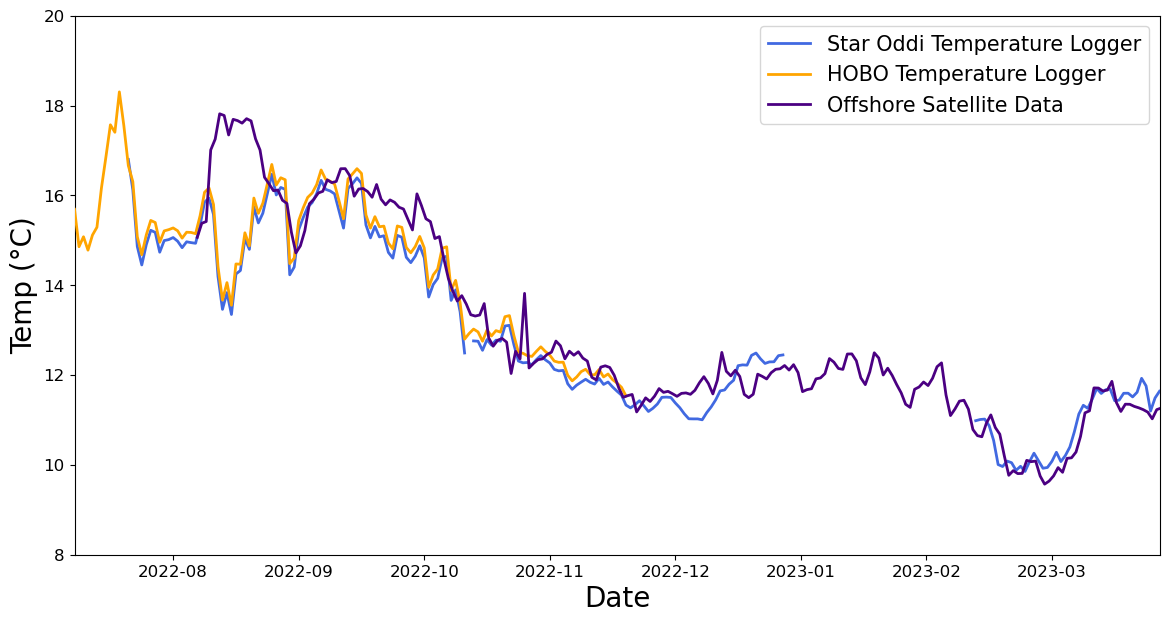

In [10]:
data_dict = {
    'Star Oddi Temperature Logger': (star_oddi_average_data['date_time'], star_oddi_average_data['temp_c_daily_average'], 'royalblue', 'line'),
    'HOBO Temperature Logger': (hobo_average_data['date_time'], hobo_average_data['temp_c_daily_average'], 'orange', 'line'),
    'Offshore Satellite Data': (ap_beach.time, ap_beach.mean(axis=(1,2)), 'indigo', 'line')
}

abiotic_plot('line', data_dict, 
            #'Fall Temperature Decrease Similarly Detected \n with Satellite and Intertidal Loggers', 
            xlabel='Date', ylabel='Temp (°C)', 
            xlim=(start_date, end_date), 
            ylim=(8, 20), 
            save_path='plots/temperature_trends_no_title.png')


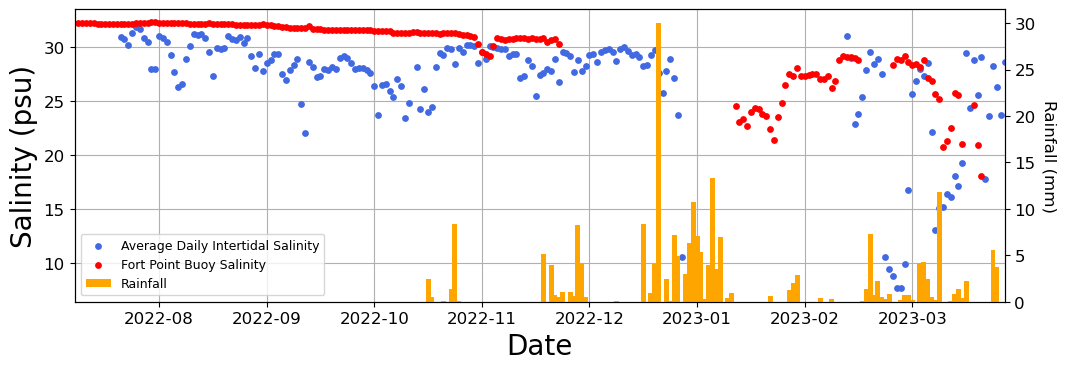

In [11]:
data_dict = {
    'Average Daily Intertidal Salinity': (star_oddi_average_data['date_time'], star_oddi_average_data['salinity_ppt_daily_average'], 'royalblue', 'scatter'),
    'Fort Point Buoy Salinity': (fort_point_daily_average_data['date_time'], fort_point_daily_average_data['salinity_ppt_daily_average'], 'red', 'scatter'),
    'rain': (precipitation_data['date_time'], precipitation_data['rain_mm'], 'orange', 'bar')
}

abiotic_plot('scatter', data_dict, 
            #'Local Rain Events Drastically Drop Intertidal Logger Salinity', 
            xlabel='Date', ylabel='Salinity (psu)', 
            xlim=(start_date, end_date), 
            save_path='figures/salinity_rainfall_no_title.png')

# Regressions

In [12]:
a_sola_algae_data = pd.read_csv('biotic_data/a_sola_algae_data.csv')
a_sola_algae_data = a_sola_algae_data[['date_time', 'num_cells_per_ug_protein']]

In [13]:
# Ensure date_time is treated as a datetime object (optional but recommended)
a_sola_algae_data['date_time'] = pd.to_datetime(a_sola_algae_data['date_time'])

# Group by date_time and calculate the mean
average_algae_by_date = a_sola_algae_data.groupby('date_time', as_index=False)['num_cells_per_ug_protein'].mean()

average_algae_by_date = average_algae_by_date.rename(columns={'num_cells_per_ug_protein':'avg_num_cells_per_ug_protein'})

# Display result
print(average_algae_by_date)

    date_time  avg_num_cells_per_ug_protein
0  2022-08-27                   1229.109180
1  2022-08-28                   1410.625774
2  2022-09-06                   1165.674312
3  2022-09-07                   1241.706010
4  2022-09-23                   1274.936744
5  2022-09-24                    939.042052
6  2022-10-10                   1169.361765
7  2022-10-11                   1022.189948
8  2022-10-27                   1375.186657
9  2022-10-28                    707.755169
10 2022-11-08                   1494.118142
11 2022-11-23                    695.890378
12 2022-12-06                    612.884032
13 2023-01-06                    685.421340
14 2023-01-23                    588.035318
15 2023-02-06                    563.501745
16 2023-02-18                    599.270588
17 2023-03-17                    447.340753


In [14]:
# Sort both DataFrames by date_time (required for merge_asof)
algae_data = average_algae_by_date
temp_data = star_oddi_seven_day_average_data.sort_values('date_time')

# Perform an asof merge to find the closest matching date
avg_algae_abiotic_data = pd.merge_asof(algae_data, temp_data, on='date_time', direction='nearest')

# Display the merged data
print(avg_algae_abiotic_data)

    date_time  avg_num_cells_per_ug_protein  temp_c_seven_day_average  \
0  2022-08-27                   1229.109180                 15.140396   
1  2022-08-28                   1410.625774                 15.140396   
2  2022-09-06                   1165.674312                 14.362901   
3  2022-09-07                   1241.706010                 14.362901   
4  2022-09-23                   1274.936744                 15.936019   
5  2022-09-24                    939.042052                 15.936019   
6  2022-10-10                   1169.361765                 15.016051   
7  2022-10-11                   1022.189948                 15.016051   
8  2022-10-27                   1375.186657                 14.007658   
9  2022-10-28                    707.755169                 12.827494   
10 2022-11-08                   1494.118142                 12.661708   
11 2022-11-23                    695.890378                 11.893495   
12 2022-12-06                    612.884032        

In [15]:
# Average over lat/lon to get a time series of daily SST
daily_satellite_sst = ap_beach.mean(dim=['latitude', 'longitude']).to_series()
daily_satellite_sst.index = pd.to_datetime(daily_satellite_sst.index)  # Ensure datetime index

In [16]:
satellite_sst_7day_avg = daily_satellite_sst.rolling(window=7, min_periods=1).mean()

In [17]:
# Step 1: Turn your SST series into a DataFrame
satellite_sst_df = satellite_sst_7day_avg.reset_index()
satellite_sst_df.columns = ['date_time', 'satellite_temp_avg']

# Step 2: Ensure both are sorted by date
avg_algae_abiotic_data = avg_algae_abiotic_data.sort_values('date_time')
satellite_sst_df = satellite_sst_df.sort_values('date_time')

# Step 3: Use merge_asof to find nearest SST for each algae sample date
avg_algae_abiotic_data = pd.merge_asof(
    avg_algae_abiotic_data,
    satellite_sst_df,
    on='date_time',
    direction='nearest',          # You can try 'backward' or 'forward' if you want to limit
    tolerance=pd.Timedelta('7D')  # Only use SST if it's within 7 days
)

# Step 4: Fill NaNs with the satellite SST values
avg_algae_abiotic_data['temp_c_seven_day_average'] = avg_algae_abiotic_data['temp_c_seven_day_average'].fillna(
    avg_algae_abiotic_data['satellite_temp_avg']
)

# (Optional) Drop the satellite column afterward
avg_algae_abiotic_data = avg_algae_abiotic_data.drop(columns=['satellite_temp_avg'])


In [18]:
model = regression(avg_algae_abiotic_data, 
                   'temp_c_seven_day_average', 
                   'avg_num_cells_per_ug_protein',
                   color='#4eb3d3', 
                   title='Algal Cell Density vs. Temperature \n (7-day average prior to sampling)',
                   save_path='plots/temp_algal_density_regression.png')

                                 OLS Regression Results                                 
Dep. Variable:     avg_num_cells_per_ug_protein   R-squared:                       0.541
Model:                                      OLS   Adj. R-squared:                  0.513
Method:                           Least Squares   F-statistic:                     18.89
Date:                          Sun, 09 Nov 2025   Prob (F-statistic):           0.000500
Time:                                  13:45:54   Log-Likelihood:                -123.18
No. Observations:                            18   AIC:                             250.4
Df Residuals:                                16   BIC:                             252.1
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------

In [19]:
model = regression(avg_algae_abiotic_data, 
                   'salinity_ppt_seven_day_average', 
                   'avg_num_cells_per_ug_protein',
                   color='#4eb3d3', 
                   title='Algal Cell Density vs. Salinity \n (7-day average prior to sampling)',
                   save_path='plots/salinity_algal_density_regression.png')

                                 OLS Regression Results                                 
Dep. Variable:     avg_num_cells_per_ug_protein   R-squared:                       0.293
Model:                                      OLS   Adj. R-squared:                  0.238
Method:                           Least Squares   F-statistic:                     5.383
Date:                          Sun, 09 Nov 2025   Prob (F-statistic):             0.0372
Time:                                  13:45:57   Log-Likelihood:                -105.44
No. Observations:                            15   AIC:                             214.9
Df Residuals:                                13   BIC:                             216.3
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------

                                 OLS Regression Results                                 
Dep. Variable:     avg_num_cells_per_ug_protein   R-squared:                       0.293
Model:                                      OLS   Adj. R-squared:                  0.238
Method:                           Least Squares   F-statistic:                     5.383
Date:                          Sun, 09 Nov 2025   Prob (F-statistic):             0.0372
Time:                                  13:58:17   Log-Likelihood:                -105.44
No. Observations:                            15   AIC:                             214.9
Df Residuals:                                13   BIC:                             216.3
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------

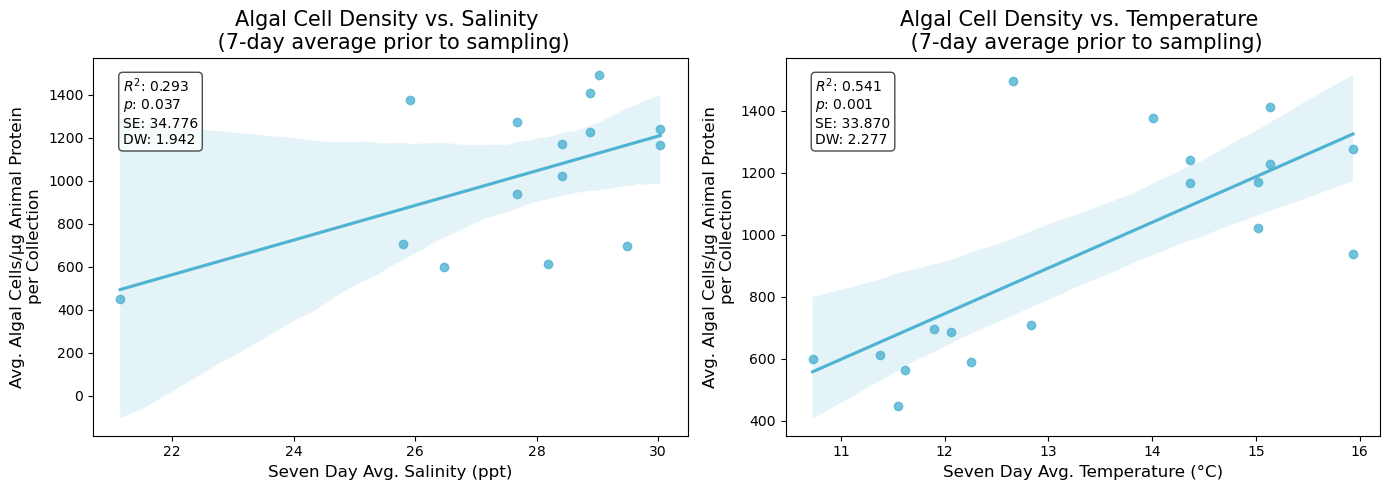

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regression(avg_algae_abiotic_data, 
                   'salinity_ppt_seven_day_average', 
                   'avg_num_cells_per_ug_protein',
                   color='#4eb3d3', 
                   title='Algal Cell Density vs. Salinity \n (7-day average prior to sampling)',
                   ax=axes[0]
)                

regression(avg_algae_abiotic_data, 
                   'temp_c_seven_day_average', 
                   'avg_num_cells_per_ug_protein',
                   color='#4eb3d3', 
                   title='Algal Cell Density vs. Temperature \n (7-day average prior to sampling)',
                   ax=axes[1])


plt.tight_layout()
fig.savefig("plots/subplot_algae_salinity_temp_regression.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
a_sola_chl_data = pd.read_csv('biotic_data/a_sola_chlorophyll_data.csv')
a_sola_chl_data = a_sola_chl_data[['date_time', 'ng_chlorophyll_per_ug_protein']]

In [23]:
# Ensure date_time is treated as a datetime object (optional but recommended)
a_sola_chl_data['date_time'] = pd.to_datetime(a_sola_chl_data['date_time'])

# Group by date_time and calculate the mean
average_chl_by_date = a_sola_chl_data.groupby('date_time', as_index=False)['ng_chlorophyll_per_ug_protein'].mean()

average_chl_by_date = average_chl_by_date.rename(columns={'ng_chlorophyll_per_ug_protein':'avg_ng_chlorophyll_per_ug_protein'})

# Display result
print(average_chl_by_date)

    date_time  avg_ng_chlorophyll_per_ug_protein
0  2022-08-27                          59.551621
1  2022-08-28                          81.910197
2  2022-09-06                          95.228443
3  2022-09-07                          91.605877
4  2022-09-23                          60.079010
5  2022-09-24                          58.627409
6  2022-10-27                          74.407994
7  2022-10-28                          28.967448
8  2022-11-08                          66.489613
9  2022-11-23                          71.075774
10 2022-12-06                          51.234062
11 2023-01-06                          33.471221
12 2023-01-23                          26.836452
13 2023-02-06                          15.725405
14 2023-02-18                          19.353205
15 2023-03-17                          18.292696


In [24]:
# Sort both DataFrames by date_time (required for merge_asof)
chl_data = average_chl_by_date
temp_data = star_oddi_seven_day_average_data.sort_values('date_time')

# Perform an asof merge to find the closest matching date
avg_chl_abiotic_data = pd.merge_asof(chl_data, temp_data, on='date_time', direction='nearest')

# Display the merged data
print(avg_chl_abiotic_data)

    date_time  avg_ng_chlorophyll_per_ug_protein  temp_c_seven_day_average  \
0  2022-08-27                          59.551621                 15.140396   
1  2022-08-28                          81.910197                 15.140396   
2  2022-09-06                          95.228443                 14.362901   
3  2022-09-07                          91.605877                 14.362901   
4  2022-09-23                          60.079010                 15.936019   
5  2022-09-24                          58.627409                 15.936019   
6  2022-10-27                          74.407994                 14.007658   
7  2022-10-28                          28.967448                 12.827494   
8  2022-11-08                          66.489613                 12.661708   
9  2022-11-23                          71.075774                 11.893495   
10 2022-12-06                          51.234062                 11.375797   
11 2023-01-06                          33.471221                

In [ ]:
# Step 1: Turn your SST series into a DataFrame
satellite_sst_df = satellite_sst_7day_avg.reset_index()
satellite_sst_df.columns = ['date_time', 'satellite_temp_avg']

# Step 2: Ensure both are sorted by date
avg_chl_abiotic_data = avg_chl_abiotic_data.sort_values('date_time')
satellite_sst_df = satellite_sst_df.sort_values('date_time')

# Step 3: Use merge_asof to find nearest SST for each algae sample date
avg_chl_abiotic_data = pd.merge_asof(
    avg_chl_abiotic_data,
    satellite_sst_df,
    on='date_time',
    direction='nearest',          # You can try 'backward' or 'forward' if you want to limit
    tolerance=pd.Timedelta('7D')  # Only use SST if it's within 7 days
)

# Step 4: Fill NaNs with the satellite SST values
avg_chl_abiotic_data['temp_c_seven_day_average'] = avg_chl_abiotic_data['temp_c_seven_day_average'].fillna(
    avg_chl_abiotic_data['satellite_temp_avg']
)

# (Optional) Drop the satellite column afterward
avg_chl_abiotic_data = avg_chl_abiotic_data.drop(columns=['satellite_temp_avg'])


In [25]:
model = regression(avg_chl_abiotic_data, 
                   'temp_c_seven_day_average', 
                   'avg_ng_chlorophyll_per_ug_protein',
                   color='#2c7fb8', 
                   title='Chlorophyll α Concentration vs. Temperature \n (7-day average prior to sampling)',
                   save_path='plots/temperature_chlorophyll_density_regression.png')

                                    OLS Regression Results                                   
Dep. Variable:     avg_ng_chlorophyll_per_ug_protein   R-squared:                       0.324
Model:                                           OLS   Adj. R-squared:                  0.263
Method:                                Least Squares   F-statistic:                     5.283
Date:                               Sun, 09 Nov 2025   Prob (F-statistic):             0.0422
Time:                                       13:59:44   Log-Likelihood:                -57.244
No. Observations:                                 13   AIC:                             118.5
Df Residuals:                                     11   BIC:                             119.6
Df Model:                                          1                                         
Covariance Type:                           nonrobust                                         
                               coef    std err          t   

In [26]:
model = regression(avg_chl_abiotic_data, 
                   'salinity_ppt_seven_day_average', 
                   'avg_ng_chlorophyll_per_ug_protein',
                   color='#2c7fb8', 
                   title='Chlorophyll α Concentration vs. Salinity \n (7-day average prior to sampling)',
                   save_path='plots/salinity_chlorophyll_density_regression.png')

                                    OLS Regression Results                                   
Dep. Variable:     avg_ng_chlorophyll_per_ug_protein   R-squared:                       0.599
Model:                                           OLS   Adj. R-squared:                  0.562
Method:                                Least Squares   F-statistic:                     16.41
Date:                               Sun, 09 Nov 2025   Prob (F-statistic):            0.00191
Time:                                       13:59:46   Log-Likelihood:                -53.859
No. Observations:                                 13   AIC:                             111.7
Df Residuals:                                     11   BIC:                             112.8
Df Model:                                          1                                         
Covariance Type:                           nonrobust                                         
                                     coef    std err        

                                    OLS Regression Results                                   
Dep. Variable:     avg_ng_chlorophyll_per_ug_protein   R-squared:                       0.599
Model:                                           OLS   Adj. R-squared:                  0.562
Method:                                Least Squares   F-statistic:                     16.41
Date:                               Sun, 09 Nov 2025   Prob (F-statistic):            0.00191
Time:                                       13:59:52   Log-Likelihood:                -53.859
No. Observations:                                 13   AIC:                             111.7
Df Residuals:                                     11   BIC:                             112.8
Df Model:                                          1                                         
Covariance Type:                           nonrobust                                         
                                     coef    std err        

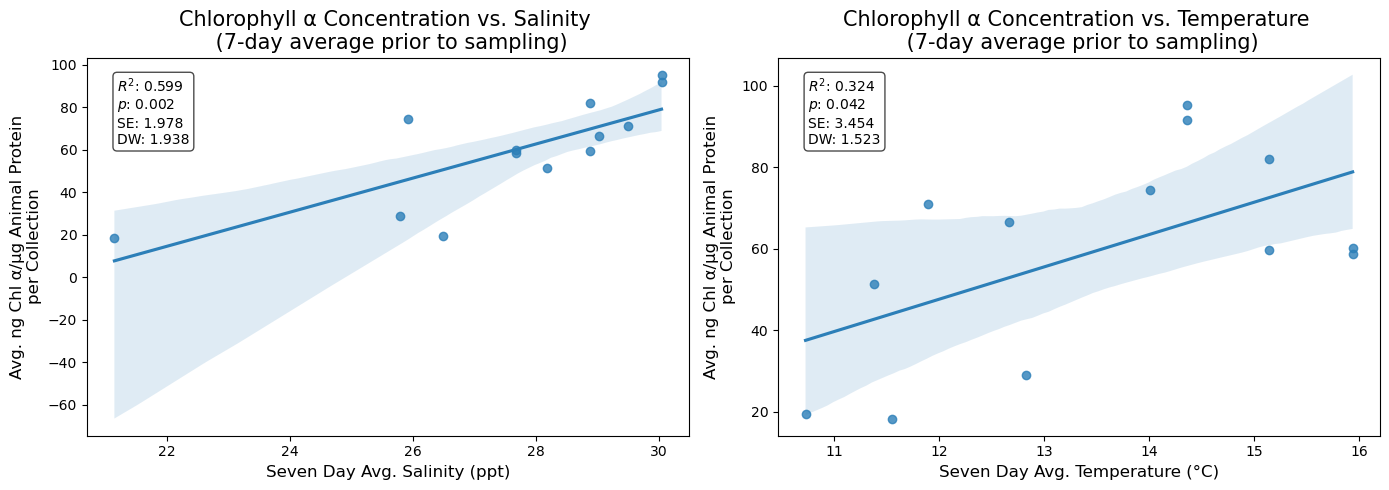

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regression(avg_chl_abiotic_data, 
                   'salinity_ppt_seven_day_average', 
                   'avg_ng_chlorophyll_per_ug_protein',
                   color='#2c7fb8', 
                   title='Chlorophyll α Concentration vs. Salinity \n (7-day average prior to sampling)',
                   ax=axes[0])

regression(avg_chl_abiotic_data, 
                   'temp_c_seven_day_average', 
                   'avg_ng_chlorophyll_per_ug_protein',
                   color='#2c7fb8', 
                   title='Chlorophyll α Concentration vs. Temperature \n (7-day average prior to sampling)',
                   ax=axes[1])

plt.tight_layout()
fig.savefig("plots/subplot_chl_salinity_temp_regression.png", dpi=300, bbox_inches="tight")
plt.show()